In [75]:
import pandas as pd
import ast

# Load the data
file_path = '../results/output_bf_04_25_1.xlsx'
round_df = pd.read_excel(file_path, sheet_name='round')
round_df = round_df.drop_duplicates(['group_id', 'domain', 'round_num'])
# round_df.to_excel('../results/round_data_old.xlsx', sheet_name='round')  #w/o duplicates

# for w/o feedback data
# metrics_df = pd.read_excel('../results/expanded_combined_metrics_analysis.xlsx')  # get group condition from this
# valid_group_ids = metrics_df['group_id'].unique()

# for w/ feedback data
valid_group_ids = round_df['group_id'].unique()
valid_group_ids = valid_group_ids[valid_group_ids >= 20]

print(valid_group_ids)

# Function to safely parse 'round_info' and extract 'env_traj_idx' values
def extract_env_traj_idx(round_info):
    try:
        parsed = ast.literal_eval(round_info)
        env_traj_idxs_demos = []
        env_traj_idxs_tests = []
        for interaction in parsed:
            if isinstance(interaction, dict) and 'params' in interaction and 'env_traj_idxs' in interaction['params'] and 'demo' in interaction['interaction type']:
                env_traj_idxs_demos.append(interaction['params']['env_traj_idxs'])
            elif isinstance(interaction, dict) and 'params' in interaction and 'env_traj_idxs' in interaction['params'] and 'diagnostic test' in interaction['interaction type']:
                env_traj_idxs_tests.append(interaction['params']['env_traj_idxs'])
        # print(env_traj_idxs_demos)
        # print(env_traj_idxs_tests)
        return env_traj_idxs_demos, env_traj_idxs_tests
    except Exception:
        return [], []

# Apply extraction
round_df[['env_traj_idxs_demos', 'env_traj_idxs_tests']] = pd.DataFrame(round_df['round_info'].apply(extract_env_traj_idx).tolist(), index=round_df.index)

# round_df.to_excel('../results/round_data_old.xlsx', sheet_name='round')  # after extracting the env_traj_idxs

##############################

# Step-by-step based on the instruction:
# 1. Group by 'group_id' and then by domain
# 2. Check how many envs_list are repeating

import ast
import pandas as pd

repeated_summary = []

for group_id, group_data in round_df.groupby('group_id'):
    if group_id in valid_group_ids:
        for domain, domain_data in group_data.groupby('domain'):
            for kc_id, kc_data in domain_data.groupby('kc_id'):

                ### --- Process DEMOS first --- ###
                env_traj_list_demos = []
                traj_idx_to_round_demo = {}

                for idx, row in kc_data.iterrows():
                    if row['env_traj_idxs_demos']:
                        traj = row['env_traj_idxs_demos']
                        if isinstance(traj, str):
                            traj = ast.literal_eval(traj)
                        traj_tuple = tuple(tuple(x) for x in traj)
                        env_traj_list_demos.append(traj_tuple)
                        traj_idx_to_round_demo.setdefault(traj_tuple, []).append(row['round_num'])

                counts_demos = {}
                for traj_tuple in env_traj_list_demos:
                    counts_demos[traj_tuple] = counts_demos.get(traj_tuple, 0) + 1

                for traj_val, count in counts_demos.items():
                    repeated_summary.append({
                        'group_id': group_id,
                        'domain': domain,
                        'kc_id': kc_id,
                        'source_type': 'demo',
                        'env_traj_idxs': traj_val,
                        'count': count,
                        'round_nums': traj_idx_to_round_demo.get(traj_val, [])
                    })

                ### --- Now Process TESTS --- ###
                env_traj_list_tests = []
                traj_idx_to_round_test = {}

                for idx, row in kc_data.iterrows():
                    if row['env_traj_idxs_tests']:
                        traj = row['env_traj_idxs_tests']
                        if isinstance(traj, str):
                            traj = ast.literal_eval(traj)
                        traj_tuple = tuple(tuple(x) for x in traj)
                        env_traj_list_tests.append(traj_tuple)
                        traj_idx_to_round_test.setdefault(traj_tuple, []).append(row['round_num'])

                counts_tests = {}
                for traj_tuple in env_traj_list_tests:
                    counts_tests[traj_tuple] = counts_tests.get(traj_tuple, 0) + 1

                for traj_val, count in counts_tests.items():
                    repeated_summary.append({
                        'group_id': group_id,
                        'domain': domain,
                        'kc_id': kc_id,
                        'source_type': 'test',
                        'env_traj_idxs': traj_val,
                        'count': count,
                        'round_nums': traj_idx_to_round_test.get(traj_val, [])
                    })

# Convert to DataFrame
repeated_summary_df = pd.DataFrame(repeated_summary)

# Show the final table
repeated_summary_df

print('Number of unique groups:', len(repeated_summary_df['group_id'].unique()))


# Plot repetitions by domain and kc_id
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Merge repeated summary with expanded metrics
# repeated_summary_df_merged = repeated_summary_df.merge(
#     metrics_df[['group_id', 'experimental_condition']].drop_duplicates(),
#     on='group_id',
#     how='left'
# )

group_df =  pd.read_excel(file_path, sheet_name='group')
group_df['group_id'] = group_df['id']


repeated_summary_df_merged = repeated_summary_df.merge(
    group_df[['group_id', 'experimental_condition']].drop_duplicates(),
    on='group_id',
    how='left'
)

repeated_summary_df_merged.to_excel('../results/repeated_rounds_with_feedback.xlsx')




[20 21 22 23 24 25 26 27]
Number of unique groups: 8


In [6]:
import os
import json
import numpy as np

base_dir = os.getcwd()

with open(os.path.join(base_dir, 'app', 'user_study_dict_extended.json'), 'r') as f:
    default_rounds = json.load(f)

# print(default_rounds)

# variable_filter = [[0. 0. 0.]]
variable_filter = np.zeros((1, 3))

domain = 'at'

games = list()
if domain == 'at':
    mdp_class = 'augmented_taxi2'
elif domain == 'sb':
    mdp_class = 'skateboard2'

interaction_types = ['demo', 'diagnostic test']

for it in interaction_types:
    for interaction_id in default_rounds[mdp_class][it].keys():
        mdp_dict = default_rounds[mdp_class][it][interaction_id]
        # # check if variable filter matches
        if (np.array(mdp_dict['variable_filter']) == variable_filter).all():
            games.append({"interaction type": it, "params": mdp_dict})  

print(games)


[{'interaction type': 'demo', 'params': {'agent': {'x': 2, 'y': 3, 'has_passenger': 0}, 'walls': [{'x': 1, 'y': 3}, {'x': 1, 'y': 2}], 'passengers': [{'x': 4, 'y': 2, 'dest_x': 1, 'dest_y': 1, 'in_taxi': 0}], 'tolls': [{'x': 3, 'y': 3}, {'x': 4, 'y': 2}], 'available_tolls': [{'x': 3, 'y': 3}, {'x': 2, 'y': 2}, {'x': 3, 'y': 2}, {'x': 4, 'y': 2}, {'x': 3, 'y': 1}], 'traffic': [], 'fuel_station': [], 'hotswap_station': [{'x': 4, 'y': 3}], 'available_hotswap_stations': [{'x': 4, 'y': 3}], 'width': 4, 'height': 3, 'gamma': 1, 'env_code': [1, 0, 0, 1, 0, 1], 'opt_locations': [[2, 3, 0], [3, 3, 0], [4, 3, 0], [4, 2, 0], [4, 2, 1], [4, 1, 1], [3, 1, 1], [2, 1, 1], [1, 1, 1], [1, 1, 0]], 'opt_actions': ['right', 'right', 'down', 'pickup', 'down', 'left', 'left', 'left', 'dropoff'], 'opt_traj_length': 9, 'opt_traj_reward': -2.4379951240146283, 'test_difficulty': 'none', 'tag': -1, 'all_opt_actions': [['right', 'right', 'down', 'pickup', 'down', 'left', 'left', 'left', 'dropoff'], ['right', 'rig

Number of unique groups: 23
unique groups: [24 27 28 29 30 31 32 33 44 46 47 49 51 52 53 54 55 57 58 59 87 88 89]


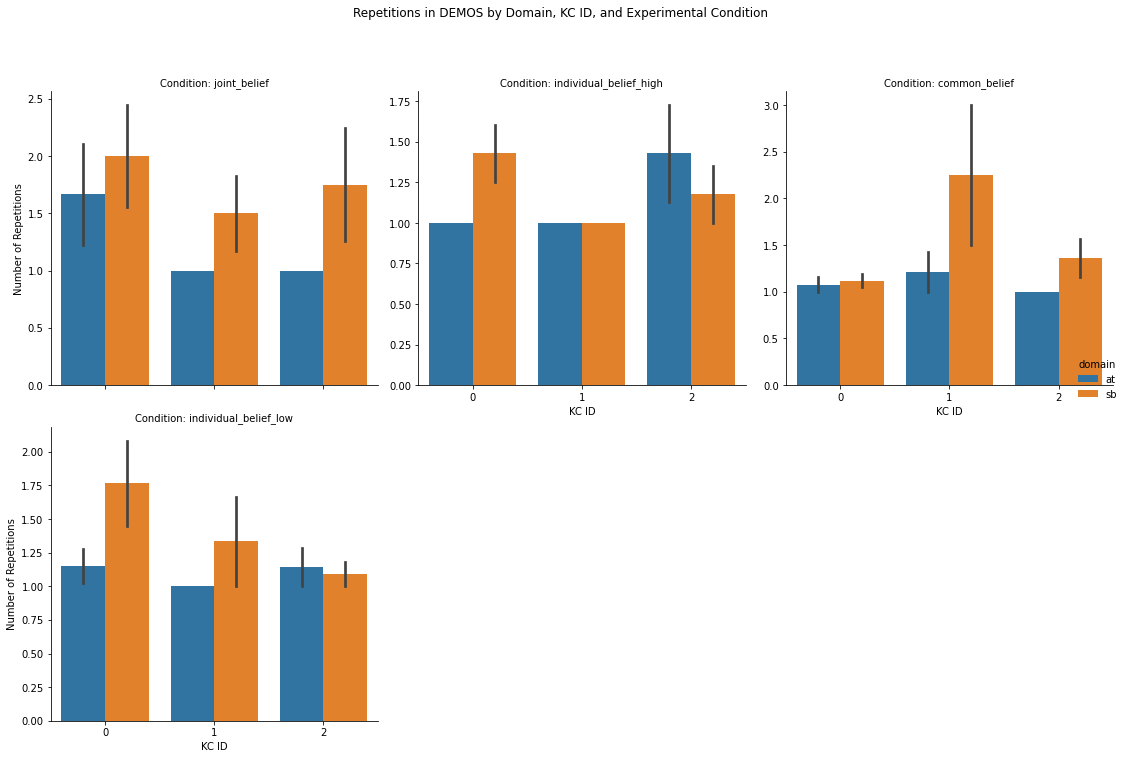

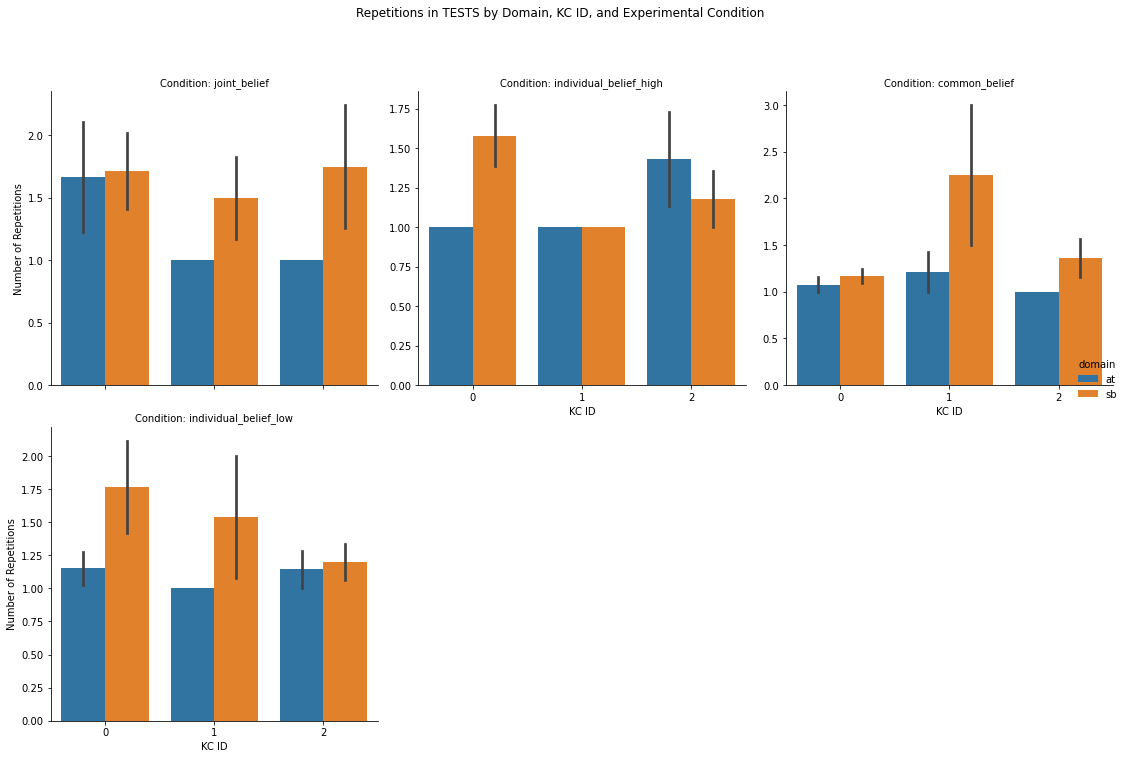

In [71]:
repeated_summary_df_merged = repeated_summary_df_merged[repeated_summary_df_merged['group_id'] <= 89]
print('Number of unique groups:', len(repeated_summary_df_merged['group_id'].unique()))
print('unique groups:', repeated_summary_df_merged['group_id'].unique())


# Step 2: Separate demos and tests
demos_df = repeated_summary_df_merged[repeated_summary_df_merged['source_type'] == 'demo']
tests_df = repeated_summary_df_merged[repeated_summary_df_merged['source_type'] == 'test']

# Step 3: Plot for demos
g_demo = sns.catplot(
    data=demos_df,
    kind='bar',
    x='kc_id',
    y='count',
    hue='domain',
    col='experimental_condition',
    errorbar='se',
    height=5,
    aspect=1,
    col_wrap=3,
    sharey=False
)
g_demo.set_axis_labels("KC ID", "Number of Repetitions")
g_demo.set_titles("Condition: {col_name}")
g_demo.fig.suptitle('Repetitions in DEMOS by Domain, KC ID, and Experimental Condition', y=1.05)
plt.tight_layout()
plt.show()

# Step 4: Plot for tests
g_test = sns.catplot(
    data=tests_df,
    kind='bar',
    x='kc_id',
    y='count',
    hue='domain',
    col='experimental_condition',
    errorbar='se',
    height=5,
    aspect=1,
    col_wrap=3,
    sharey=False
)
g_test.set_axis_labels("KC ID", "Number of Repetitions")
g_test.set_titles("Condition: {col_name}")
g_test.fig.suptitle('Repetitions in TESTS by Domain, KC ID, and Experimental Condition', y=1.05)
plt.tight_layout()
plt.show()

<class 'numpy.int64'>
Number of unique groups: 23
Number of unique groups: [24 27 28 29 30 31 32 33 44 46 47 49 51 52 53 54 55 57 58 59 87 88 89]
Plotting for Demo data...


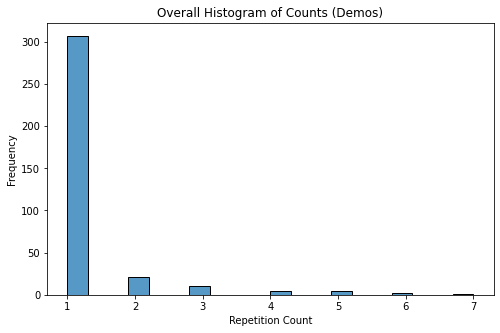

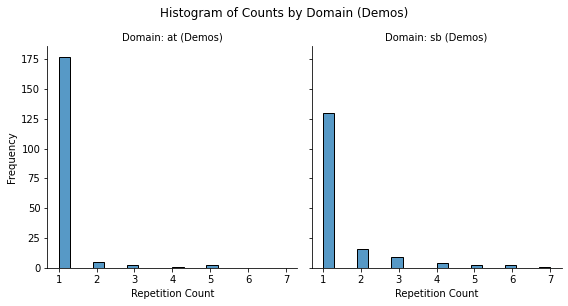

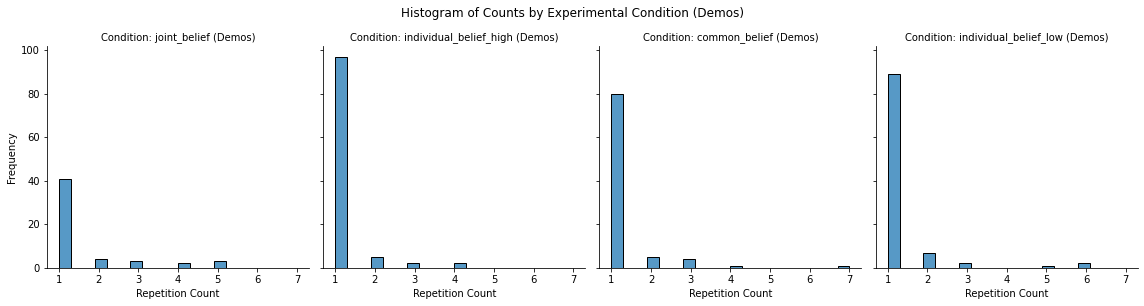

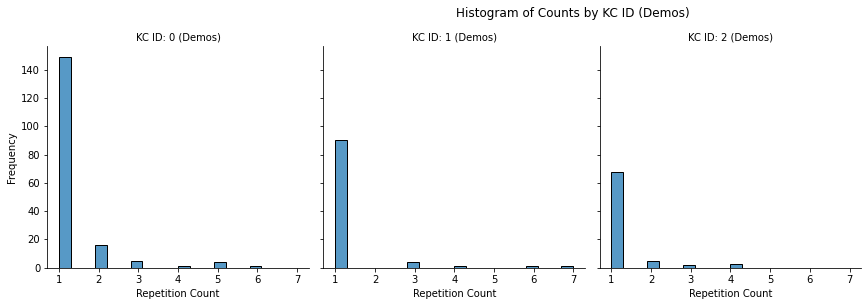

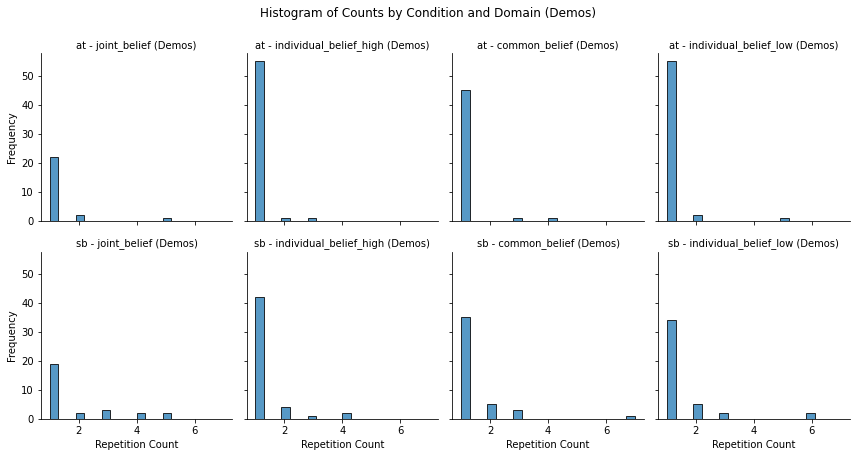

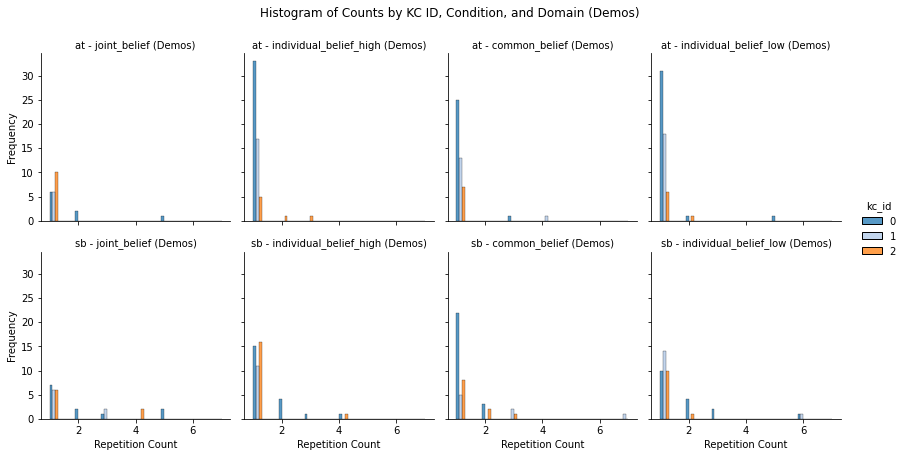

Plotting for Test data...


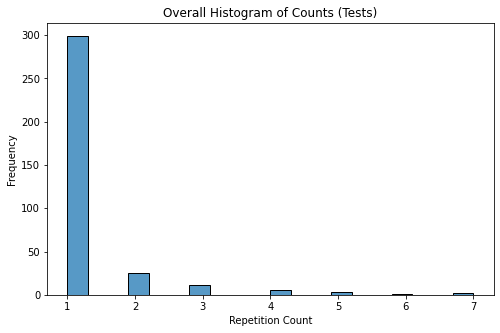

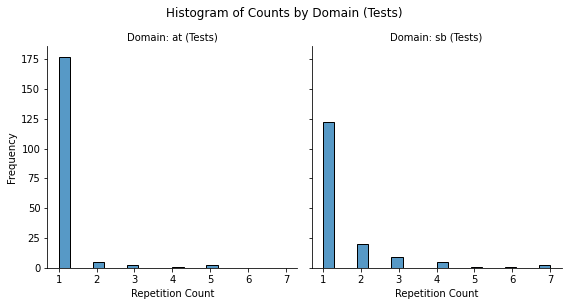

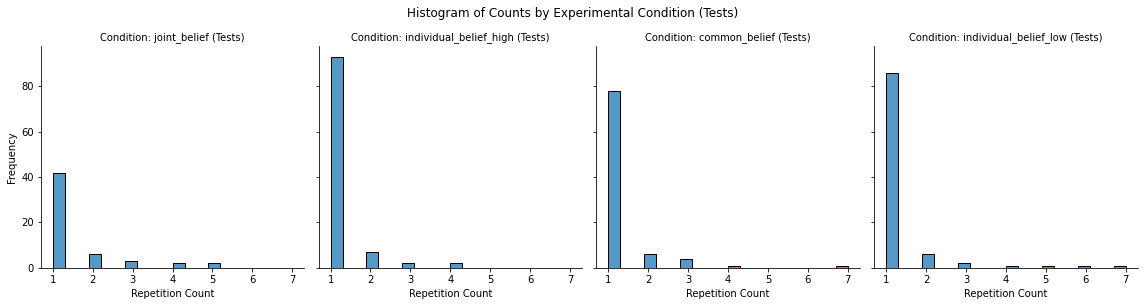

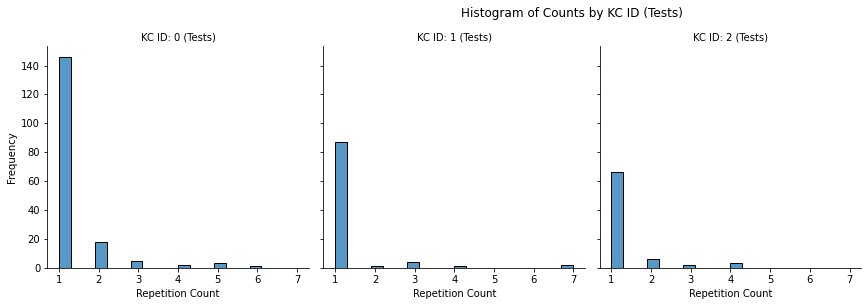

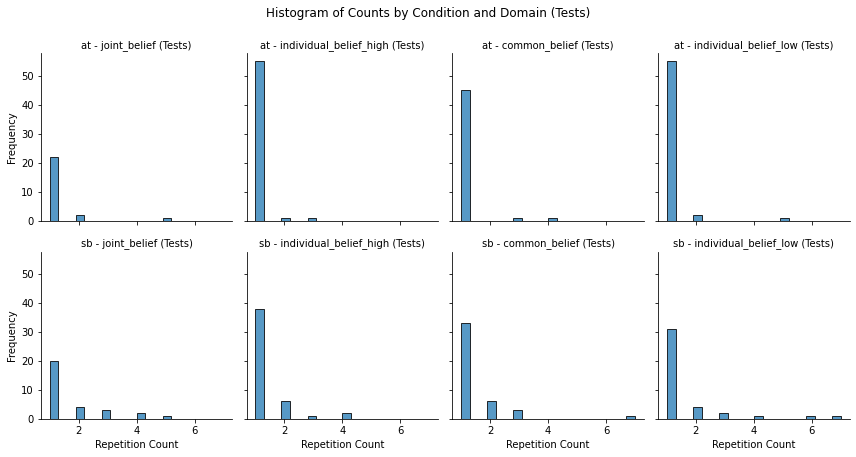

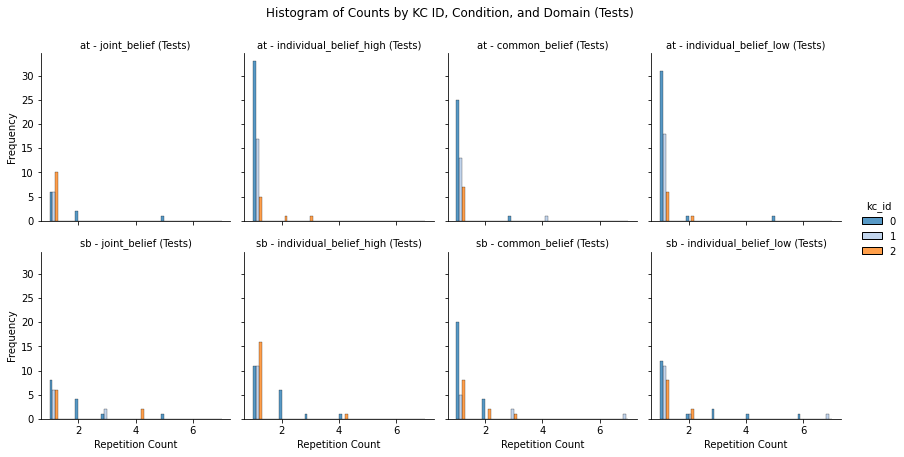

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

repeated_summary_df_merged = repeated_summary_df_merged[repeated_summary_df_merged['group_id'] <= 89]
print('Number of unique groups:', len(repeated_summary_df_merged['group_id'].unique()))
print('unique groups:', repeated_summary_df_merged['group_id'].unique())



# Split dataset
demos_df = repeated_summary_df_merged[repeated_summary_df_merged['source_type'] == 'demo']
tests_df = repeated_summary_df_merged[repeated_summary_df_merged['source_type'] == 'test']

datasets = {'Demo': demos_df, 'Test': tests_df}

# Plot for each dataset separately
for label, df in datasets.items():
    print(f"Plotting for {label} data...")
    
    # (1) Overall histogram
    plt.figure(figsize=(8, 5))
    sns.histplot(df['count'], bins=20, kde=False)
    plt.title(f'Overall Histogram of Counts ({label}s)')
    plt.xlabel('Repetition Count')
    plt.ylabel('Frequency')
    plt.show()

    # (2) Histogram by domain
    g = sns.displot(
        data=df,
        x='count',
        col='domain',
        bins=20,
        kde=False,
        height=4,
        aspect=1
    )
    g.set_titles(f'Domain: {{col_name}} ({label}s)')
    g.set_axis_labels('Repetition Count', 'Frequency')
    g.fig.suptitle(f'Histogram of Counts by Domain ({label}s)', y=1.05)
    plt.show()

    # (2b) Histogram by experimental condition
    g = sns.displot(
        data=df,
        x='count',
        col='experimental_condition',
        bins=20,
        kde=False,
        height=4,
        aspect=1
    )
    g.set_titles(f'Condition: {{col_name}} ({label}s)')
    g.set_axis_labels('Repetition Count', 'Frequency')
    g.fig.suptitle(f'Histogram of Counts by Experimental Condition ({label}s)', y=1.05)
    plt.show()

    # (2c) Histogram by kc_id
    g = sns.displot(
        data=df,
        x='count',
        col='kc_id',
        bins=20,
        kde=False,
        height=4,
        aspect=1,
        col_wrap=4
    )
    g.set_titles(f'KC ID: {{col_name}} ({label}s)')
    g.set_axis_labels('Repetition Count', 'Frequency')
    g.fig.suptitle(f'Histogram of Counts by KC ID ({label}s)', y=1.05)
    plt.show()

    # (3) Histogram by condition and domain
    g = sns.displot(
        data=df,
        x='count',
        col='experimental_condition',
        row='domain',
        bins=20,
        kde=False,
        height=3,
        aspect=1
    )
    g.set_axis_labels('Repetition Count', 'Frequency')
    g.set_titles(f'{{row_name}} - {{col_name}} ({label}s)')
    g.fig.suptitle(f'Histogram of Counts by Condition and Domain ({label}s)', y=1.05)
    plt.show()

    # (4) Histogram by kc_id, condition, and domain
    g = sns.displot(
        data=df,
        x='count',
        col='experimental_condition',
        row='domain',
        hue='kc_id',
        multiple='dodge',
        bins=20,
        height=3,
        aspect=1,
        palette='tab20'
    )
    g.set_axis_labels('Repetition Count', 'Frequency')
    g.set_titles(f'{{row_name}} - {{col_name}} ({label}s)')
    g.fig.suptitle(f'Histogram of Counts by KC ID, Condition, and Domain ({label}s)', y=1.05)
    plt.show()


## Parse user activity 

In [86]:
import json
import pandas as pd
from datetime import datetime

# Load raw JSON data (replace with your full string)
json_data = '''[{"t":"14-11-05","e":"pageInitialized","u":"/"},{"t":"14-11-05","e":"nav","u":"/"},{"t":"14-11-05","e":"psh","u":"/"},{"t":"14-11-06","e":"mdn","tg":"a"},{"t":"14-11-06","e":"mup"},{"t":"14-11-06","e":"clk","tg":"a"},{"t":"14-11-06","e":"bun","u":"/"},{"t":"14-11-06","e":"phd","u":"/"},{"t":"14-11-06","e":"vch","u":"/"},{"t":"14-11-06","e":"unl","u":"/"},{"t":"14-11-06","e":"pageInitialized","u":"/consent"},{"t":"14-11-06","e":"nav","u":"/consent"},{"t":"14-11-06","e":"psh","u":"/consent"},{"t":"14-11-07","e":"blr","u":"/consent"},{"t":"14-11-57","e":"foc","u":"/consent"},{"t":"14-11-58","e":"mdn","tg":"p"},{"t":"14-11-58","e":"mup"},{"t":"14-11-58","e":"clk","tg":"p"},{"t":"14-11-59","e":"mdn","tg":"sign_consent"},{"t":"14-11-59","e":"mup"},{"t":"14-11-59","e":"clk","tg":"sign_consent"},{"t":"14-11-59","e":"bun","u":"/consent"},{"t":"14-11-59","e":"phd","u":"/consent"},{"t":"14-11-59","e":"vch","u":"/consent"},{"t":"14-11-59","e":"unl","u":"/consent"},{"t":"14-11-59","e":"pageInitialized","u":"/introduction"},{"t":"14-11-59","e":"nav","u":"/introduction"},{"t":"14-11-59","e":"psh","u":"/introduction"},{"t":"14-13-22","e":"mdn","tg":"next"},{"t":"14-13-22","e":"mup"},{"t":"14-13-22","e":"bun","u":"/introduction"},{"t":"14-13-22","e":"clk","tg":"next"},{"t":"14-13-22","e":"phd","u":"/introduction"},{"t":"14-13-22","e":"vch","u":"/introduction"},{"t":"14-13-22","e":"unl","u":"/introduction"},{"t":"14-13-22","e":"pageInitialized","u":"/overview"},{"t":"14-13-22","e":"nav","u":"/overview"},{"t":"14-13-22","e":"psh","u":"/overview"},{"t":"14-13-24","e":"mdn","tg":"next"},{"t":"14-13-24","e":"mup"},{"t":"14-13-24","e":"bun","u":"/overview"},{"t":"14-13-24","e":"clk","tg":"next"},{"t":"14-13-24","e":"phd","u":"/overview"},{"t":"14-13-24","e":"vch","u":"/overview"},{"t":"14-13-24","e":"unl","u":"/overview"},{"t":"14-13-24","e":"pageInitialized","u":"/sandbox_introduction"},{"t":"14-13-24","e":"nav","u":"/sandbox_introduction"},{"t":"14-13-24","e":"psh","u":"/sandbox_introduction"},{"t":"14-13-26","e":"mdn","tg":"next"},{"t":"14-13-26","e":"mup"},{"t":"14-13-26","e":"clk","tg":"next"},{"t":"14-13-26","e":"bun","u":"/sandbox_introduction"},{"t":"14-13-26","e":"phd","u":"/sandbox_introduction"},{"t":"14-13-26","e":"vch","u":"/sandbox_introduction"},{"t":"14-13-26","e":"unl","u":"/sandbox_introduction"},{"t":"14-13-26","e":"pageInitialized","u":"/sandbox"},{"t":"14-13-26","e":"nav","u":"/sandbox"},{"t":"14-13-26","e":"psh","u":"/sandbox"},{"t":"14-13-27","e":"blr","u":"/sandbox"},{"t":"14-13-31","e":"foc","u":"/sandbox"},{"t":"14-13-33","e":"mdn","tg":"div"},{"t":"14-13-34","e":"mup"},{"t":"14-13-34","e":"clk","tg":"div"},{"t":"14-13-34","e":"kdn","k":"Spc","m":0,"tg":"body"},{"t":"14-13-34","e":"kup","k":"Spc","m":0},{"t":"14-13-34","e":"kdn","k":"Spc","m":0,"tg":"body"},{"t":"14-13-34","e":"kup","k":"Spc","m":0},{"t":"14-13-35","e":"mdn","tg":"next"},{"t":"14-13-35","e":"mup"},{"t":"14-13-35","e":"clk","tg":"next"},{"t":"14-13-35","e":"bun","u":"/sandbox"},{"t":"14-13-35","e":"phd","u":"/sandbox"},{"t":"14-13-35","e":"vch","u":"/sandbox"},{"t":"14-13-35","e":"unl","u":"/sandbox"},{"t":"14-13-35","e":"pageInitialized","u":"/sandbox"},{"t":"14-13-36","e":"nav","u":"/sandbox"},{"t":"14-13-36","e":"psh","u":"/sandbox"},{"t":"14-13-37","e":"blr","u":"/sandbox"},{"t":"14-13-39","e":"foc","u":"/sandbox"},{"t":"14-13-39","e":"blr","u":"/sandbox"},{"t":"14-13-41","e":"foc","u":"/sandbox"},{"t":"14-13-41","e":"mdn","tg":"game"},{"t":"14-13-41","e":"mup"},{"t":"14-13-41","e":"clk","tg":"game"},{"t":"14-13-42","e":"kdn","k":"Left","m":0,"tg":"body"},{"t":"14-13-42","e":"kup","k":"Left","m":0},{"t":"14-13-42","e":"kdn","k":"Left","m":0,"tg":"body"},{"t":"14-13-42","e":"kup","k":"Left","m":0},{"t":"14-13-42","e":"kdn","k":"Left","m":0,"tg":"body"},{"t":"14-13-42","e":"kup","k":"Left","m":0},{"t":"14-13-42","e":"kdn","k":"Up","m":0,"tg":"body"},{"t":"14-13-42","e":"kup","k":"Up","m":0},{"t":"14-13-43","e":"kdn","k":"p","m":0,"tg":"body"},{"t":"14-13-43","e":"kup","k":"p","m":0},{"t":"14-13-44","e":"kdn","k":"Right","m":0,"tg":"body"},{"t":"14-13-44","e":"kup","k":"Right","m":0},{"t":"14-13-44","e":"kdn","k":"Right","m":0,"tg":"body"},{"t":"14-13-44","e":"kup","k":"Right","m":0},{"t":"14-13-44","e":"kdn","k":"Right","m":0,"tg":"body"},{"t":"14-13-44","e":"kup","k":"Right","m":0},{"t":"14-13-44","e":"kdn","k":"Right","m":0,"tg":"body"},{"t":"14-13-45","e":"kup","k":"Right","m":0},{"t":"14-13-45","e":"kdn","k":"Right","m":0,"tg":"body"},{"t":"14-13-45","e":"kup","k":"Right","m":0},{"t":"14-13-45","e":"kdn","k":"Up","m":0,"tg":"body"},{"t":"14-13-45","e":"kup","k":"Up","m":0},{"t":"14-13-45","e":"kdn","k":"Up","m":0,"tg":"body"},{"t":"14-13-45","e":"kup","k":"Up","m":0},{"t":"14-13-45","e":"kdn","k":"Left","m":0,"tg":"body"},{"t":"14-13-45","e":"kup","k":"Left","m":0},{"t":"14-13-45","e":"kdn","k":"Left","m":0,"tg":"body"},{"t":"14-13-45","e":"kup","k":"Left","m":0},{"t":"14-13-46","e":"kdn","k":"Left","m":0,"tg":"body"},{"t":"14-13-46","e":"kup","k":"Left","m":0},{"t":"14-13-46","e":"kdn","k":"d","m":0,"tg":"body"},{"t":"14-13-46","e":"kup","k":"d","m":0},{"t":"14-13-48","e":"mdn","tg":"next"},{"t":"14-13-48","e":"mup"},{"t":"14-13-48","e":"bun","u":"/sandbox"},{"t":"14-13-48","e":"clk","tg":"next"},{"t":"14-13-48","e":"phd","u":"/sandbox"},{"t":"14-13-48","e":"vch","u":"/sandbox"},{"t":"14-13-48","e":"unl","u":"/sandbox"},{"t":"14-13-48","e":"pageInitialized","u":"/post_practice"},{"t":"14-13-48","e":"nav","u":"/post_practice"},{"t":"14-13-48","e":"psh","u":"/post_practice"},{"t":"14-13-50","e":"mdn","tg":"next"},{"t":"14-13-50","e":"mup"},{"t":"14-13-50","e":"bun","u":"/post_practice"},{"t":"14-13-50","e":"clk","tg":"next"},{"t":"14-13-50","e":"phd","u":"/post_practice"},{"t":"14-13-50","e":"vch","u":"/post_practice"},{"t":"14-13-50","e":"unl","u":"/post_practice"},{"t":"14-13-50","e":"pageInitialized","u":"/waiting_room"},{"t":"14-13-50","e":"nav","u":"/waiting_room"},{"t":"14-13-50","e":"psh","u":"/waiting_room"},{"t":"14-13-50","e":"bun","u":"/waiting_room"},{"t":"14-13-50","e":"phd","u":"/waiting_room"},{"t":"14-13-50","e":"vch","u":"/waiting_room"},{"t":"14-13-50","e":"unl","u":"/waiting_room"},{"t":"14-13-50","e":"pageInitialized","u":"/sb_intro"},{"t":"14-13-51","e":"nav","u":"/sb_intro"},{"t":"14-13-51","e":"psh","u":"/sb_intro"},{"t":"14-13-55","e":"blr","u":"/sb_intro"},{"t":"14-14-01","e":"foc","u":"/sb_intro"},{"t":"14-14-01","e":"mdn","tg":"next"},{"t":"14-14-01","e":"mup"},{"t":"14-14-01","e":"bun","u":"/sb_intro"},{"t":"14-14-01","e":"clk","tg":"next"},{"t":"14-14-01","e":"phd","u":"/sb_intro"},{"t":"14-14-01","e":"vch","u":"/sb_intro"},{"t":"14-14-01","e":"unl","u":"/sb_intro"},{"t":"14-14-01","e":"pageInitialized","u":"/sb"},{"t":"14-14-02","e":"nav","u":"/sb"},{"t":"14-14-02","e":"psh","u":"/sb"},{"t":"14-14-04","e":"blr","u":"/sb"},{"t":"14-14-54","e":"foc","u":"/sb"},{"t":"14-14-54","e":"mdn","tg":"div"},{"t":"14-14-54","e":"kdn","k":"Spc","m":0,"tg":"body"},{"t":"14-14-54","e":"kup","k":"Spc","m":0},{"t":"14-14-54","e":"kdn","k":"Spc","m":0,"tg":"body"},{"t":"14-14-54","e":"mup"},{"t":"14-14-54","e":"clk","tg":"div"},{"t":"14-14-54","e":"kup","k":"Spc","m":0},{"t":"14-14-54","e":"kdn","k":"Spc","m":0,"tg":"body"},{"t":"14-14-54","e":"kup","k":"Spc","m":0},{"t":"14-14-54","e":"kdn","k":"Spc","m":0,"tg":"body"},{"t":"14-14-54","e":"kup","k":"Spc","m":0},{"t":"14-14-54","e":"kdn","k":"Spc","m":0,"tg":"body"},{"t":"14-14-54","e":"kup","k":"Spc","m":0},{"t":"14-14-55","e":"kdn","k":"Spc","m":0,"tg":"body"},{"t":"14-14-55","e":"kup","k":"Spc","m":0},{"t":"14-14-55","e":"kdn","k":"Spc","m":0,"tg":"body"},{"t":"14-14-55","e":"kup","k":"Spc","m":0},{"t":"14-14-55","e":"kdn","k":"Spc","m":0,"tg":"body"},{"t":"14-14-55","e":"kup","k":"Spc","m":0},{"t":"14-14-55","e":"kdn","k":"Spc","m":0,"tg":"body"},{"t":"14-14-55","e":"kup","k":"Spc","m":0},{"t":"14-14-55","e":"kdn","k":"Spc","m":0,"tg":"body"},{"t":"14-14-56","e":"kup","k":"Spc","m":0},{"t":"14-14-57","e":"mdn","tg":"span"},{"t":"14-14-57","e":"mup"},{"t":"14-14-57","e":"clk","tg":"span"},{"t":"14-14-57","e":"clk","tg":"input"},{"t":"14-14-57","e":"inp","tg":"input"},{"t":"14-14-57","e":"chg","tg":"input"},{"t":"14-14-58","e":"mdn","tg":"next"},{"t":"14-14-58","e":"mup"},{"t":"14-14-58","e":"bun","u":"/sb"},{"t":"14-14-58","e":"clk","tg":"next"},{"t":"14-14-58","e":"phd","u":"/sb"},{"t":"14-14-58","e":"vch","u":"/sb"},{"t":"14-14-58","e":"unl","u":"/sb"},{"t":"14-14-58","e":"pageInitialized","u":"/sb"},{"t":"14-14-58","e":"nav","u":"/sb"},{"t":"14-14-58","e":"psh","u":"/sb"}]

'''



# Parse the JSON string
events = json.loads(json_data)

print(events)

# Convert to DataFrame
df = pd.DataFrame(events)

print(df)

df.to_excel('../results/user97_activity_debug.xlsx')

# Parse timestamp string into datetime object
def parse_timestamp(ts):
    try:
        return datetime.strptime(ts, "%y-%m-%d-%H-%M-%S")
    except:
        return None

df['timestamp'] = df['t'].apply(parse_timestamp)
df.drop(columns='t', inplace=True)

# Ensure all expected optional fields are present
optional_cols = ['e', 'u', 'hidden', 'k', 'm', 'x', 'y', 'tg']
for col in optional_cols:
    if col not in df.columns:
        df[col] = None

# Reorder columns for readability
df = df[['timestamp', 'e', 'u', 'hidden', 'k', 'm', 'x', 'y', 'tg']]

# Show the head of the DataFrame
# df.head()


[{'t': '14-11-05', 'e': 'pageInitialized', 'u': '/'}, {'t': '14-11-05', 'e': 'nav', 'u': '/'}, {'t': '14-11-05', 'e': 'psh', 'u': '/'}, {'t': '14-11-06', 'e': 'mdn', 'tg': 'a'}, {'t': '14-11-06', 'e': 'mup'}, {'t': '14-11-06', 'e': 'clk', 'tg': 'a'}, {'t': '14-11-06', 'e': 'bun', 'u': '/'}, {'t': '14-11-06', 'e': 'phd', 'u': '/'}, {'t': '14-11-06', 'e': 'vch', 'u': '/'}, {'t': '14-11-06', 'e': 'unl', 'u': '/'}, {'t': '14-11-06', 'e': 'pageInitialized', 'u': '/consent'}, {'t': '14-11-06', 'e': 'nav', 'u': '/consent'}, {'t': '14-11-06', 'e': 'psh', 'u': '/consent'}, {'t': '14-11-07', 'e': 'blr', 'u': '/consent'}, {'t': '14-11-57', 'e': 'foc', 'u': '/consent'}, {'t': '14-11-58', 'e': 'mdn', 'tg': 'p'}, {'t': '14-11-58', 'e': 'mup'}, {'t': '14-11-58', 'e': 'clk', 'tg': 'p'}, {'t': '14-11-59', 'e': 'mdn', 'tg': 'sign_consent'}, {'t': '14-11-59', 'e': 'mup'}, {'t': '14-11-59', 'e': 'clk', 'tg': 'sign_consent'}, {'t': '14-11-59', 'e': 'bun', 'u': '/consent'}, {'t': '14-11-59', 'e': 'phd', 'u'

In [ ]:
def numberOfBeautifulIntegers(low, high, k):
        """
        :type low: int
        :type high: int
        :type k: int
        :rtype: int
        """
        
        # Assumptions: There is a solution for every input

        # 1) Find numbers divisible by k (easier of the two)
        # find first digit divisible by k
        candidate_start = low+k
        for i in range(low, low+k):
            if i % k == 0:
                candidate_start = i
                continue
        
        candidate_nos = list(range(candidate_start, high+1, k))


        # 2) Find numbers with equal even and odd
        beautiful_nos = []
        for cand_no in candidate_nos:
            
            digits = [int(i) for i in list(str(cand_no))]
            
            print('digits:', digits)
            
            N = len(digits)
            
            if N % 2 == 1:
                continue
            
            N_even = len([i for i in digits if i % 2 == 0])

            if N_even == N/2:
                beautiful_nos.append(cand_no)
            
        
        return beautiful_nos


low = 349863935
high = 772153463
k = 11
numberOfBeautifulIntegers(low, high, k)